# **CS 224 Final Project**


This project aims to identify sequences of bat chirps which occur frequently in bat communication so that biologists might be able to discern contextual meaning from recordings of bats in the wild.

This project analyzes 41,774 bat chirps from 2929 different recordings collected from an outdoor microphone at Jasper Ridge Biological Preserve between 01/02/2022 and 02/09/2022, and uses Graph Attention Transformers and HDBSCAN to identify clusters of acoustically similar chirp sequences.



In [1]:
!pip install torch_geometric

import pandas as pd
import torch
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from torch_geometric.data import Data

/opt/anaconda3/envs/BatGPT/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Data Preprocessing


### **Data Cleaning**
First, we clean the data and remove irrelevant or non-numerical columns. We remove most amplitude related features because the amplitude of a chirp says more about how close the bat was to the microphone when it uttered the chirp than it does about intrinsic acoustic properties of the chirp. We keep amplitude features such as variance and skew in order to preserve relative measures of amplitude.

In [2]:

#Import data
df = pd.read_csv('Files_above_length_8.csv')

# Define columns to remove directly
columns_to_remove_direct = ['Path', 'Filename', 'TimeInFile', 'ParentDir', 'NextDirUp', 'Version', 'Filter']

# Identify columns with 'Amp' in their names, excluding the specified ones
keep = ["AmpVariance", "AmpKurtosis", "AmpSkew", "AmpGausR2"]
amp_columns = [col for col in df.columns if 'Amp' in col and col not in keep]

# Remove columns
all_columns_to_remove = list(set(columns_to_remove_direct + amp_columns))
df = df.drop(columns=all_columns_to_remove, errors='ignore')

kept_columns = list(df.columns)
#print(f"Kept columns: {kept_columns}")

print(df.shape)


(41774, 85)


### **PCA**
Next, we normalize our features and perform PCA to reduce the number of dimensions from 85 to 32. This explains 92.55% of the variance.

In [3]:
# Exclude 'FileID' and 'PrecedingIntrvl' columns from features before scaling and PCA
df_features = df.drop(columns=['FileID', 'PrecedingIntrvl'])

# Normalize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_features)

# Perform PCA with 32 components
pca = PCA(n_components=32)
pca.fit(scaled_data)

# Print explained variance
explained_variance = np.sum(pca.explained_variance_ratio_)
print(f"Total variance explained by 32 components: {explained_variance:.4f}")

#Create new dataframe with PCA features
pca_features = pca.transform(scaled_data)
pca_columns = [f'PC{i+1}' for i in range(pca_features.shape[1])]
df_pca_features = pd.DataFrame(data=pca_features, columns=pca_columns)

#Combine PCA with FileID and PrecedingIntrvl for grouping and edge features
df_original_metadata = df[['FileID', 'PrecedingIntrvl']]
df_pca = pd.concat([df_original_metadata, df_pca_features], axis=1)
print("Shape of df_pca:", df_pca.shape)
#print("First 5 rows of df_pca:")
#print(df_pca.head())

Total variance explained by 32 components: 0.9341
Shape of df_pca: (41774, 34)


### **Make Graphs for each Recording**

For each FileId, we create a **bidirectional** graph with PCA features for each chirp as node features. Edge features use `log(1 + Δt)` transformed time intervals, normalized globally across all recordings. Bidirectional edges allow context to flow both forward and backward in time, which helps create richer embeddings.


In [4]:
#Calculating stats of edge features for sanity check purposes
all_log_intervals = []

for file_id, group in df_pca.groupby('FileID'):
    preceding_intervals = group['PrecedingIntrvl'].iloc[1:].values
    log_intervals = np.log1p(preceding_intervals)  # log(1 + Δt), always positive
    all_log_intervals.extend(log_intervals)

all_log_intervals = np.array(all_log_intervals)
edge_min = all_log_intervals.min()
edge_max = all_log_intervals.max()

print(f"Edge feature statistics (log-transformed, before normalization):")
print(f"  Min: {edge_min:.4f}, Max: {edge_max:.4f}")
print(f"  Mean: {all_log_intervals.mean():.4f}, Std: {all_log_intervals.std():.4f}")

# Create graphs with bidirectional edges and MIN-MAX normalized edge features
graphs = []
file_ids = []  # Keep track of FileIDs for later reference

for file_id, group in df_pca.groupby('FileID'):
    # Define node features (x)
    node_features_df = group.drop(columns=['FileID', 'PrecedingIntrvl'])
    x = torch.tensor(node_features_df.values, dtype=torch.float)
    num_nodes = x.size(0)
    
    # Initialize edge features
    edge_index = torch.empty((2, 0), dtype=torch.long)
    edge_attr = torch.empty((0,), dtype=torch.float)
    
    if num_nodes > 1:
        # Create BIDIRECTIONAL edges: i <-> i+1
        forward_source = list(range(num_nodes - 1))
        forward_target = list(range(1, num_nodes))
        backward_source = list(range(1, num_nodes))
        backward_target = list(range(num_nodes - 1))
        
        source_nodes = forward_source + backward_source
        target_nodes = forward_target + backward_target
        edge_index = torch.tensor([source_nodes, target_nodes], dtype=torch.long)
        
        # Edge features: log(1 + Δt), min-max normalized to [0, 1]
        preceding_intervals = group['PrecedingIntrvl'].iloc[1:].values
        log_intervals = np.log1p(preceding_intervals)
        
        # Min-max normalization (all values positive, in [0, 1])
        normalized_intervals = (log_intervals - edge_min) / (edge_max - edge_min + 1e-8)
        
        # Both directions get the same edge feature
        edge_features = np.concatenate([normalized_intervals, normalized_intervals])
        edge_attr = torch.tensor(edge_features, dtype=torch.float)
    
    #Add to graphs list
    graph = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    graphs.append(graph)
    file_ids.append(file_id)

print(f"\nCreated {len(graphs)} graphs with bidirectional edges.")
print(f"Edge features are min-max normalized to [0, 1]")
if graphs:
    print(f"\nFirst graph: {graphs[0].num_nodes} nodes, {graphs[0].num_edges} edges")
    print(f"100th graph: {graphs[99].num_nodes} nodes, {graphs[99].num_edges} edges")
    print(edge_attr)

Edge feature statistics (log-transformed, before normalization):
  Min: 2.3026, Max: 6.7452
  Mean: 4.4609, Std: 0.3988

Created 2929 graphs with bidirectional edges.
Edge features are min-max normalized to [0, 1]

First graph: 8 nodes, 14 edges
100th graph: 14 nodes, 26 edges
tensor([0.4535, 0.4443, 0.4033, 0.3995, 0.4535, 0.4790, 0.4921, 0.4763, 0.5020,
        0.4790, 0.4843, 0.4348, 0.3878, 0.4535, 0.4443, 0.4033, 0.3995, 0.4535,
        0.4790, 0.4921, 0.4763, 0.5020, 0.4790, 0.4843, 0.4348, 0.3878])


## **Sanity Checks**

We verify:
1. Total number of graphs created (should be 2,929)
2. Number of nodes and edges per graph (edges should be 2×(n-1) for bidirectional)
3. Node feature shape (should be [num_nodes, 32])
4. Edge features are min-max normalized to [0, 1] where:
   - 0 = shortest time interval (closest chirps)
   - 1 = longest time interval (most distant chirps)


In [5]:
# SANITY CHECK

print(f"Total number of graphs created: {len(graphs)}")
print(f"Expected: 2,929\n")

# Check edge feature range across ALL graphs
all_edge_attrs = torch.cat([g.edge_attr for g in graphs if g.num_edges > 0])
print(f"Edge feature statistics (should be in [0, 1]):")
print(f"  Min: {all_edge_attrs.min().item():.4f}")
print(f"  Max: {all_edge_attrs.max().item():.4f}")
print(f"  Mean: {all_edge_attrs.mean().item():.4f}")
print(f"  All positive: {torch.all(all_edge_attrs >= 0).item()}")
print(f"  All <= 1: {torch.all(all_edge_attrs <= 1).item()}")

# Inspect a few sample graphs
print("\n" + "="*50)
print("Inspecting first 3 sample graphs:")
for i, graph in enumerate(graphs[:3]):
    print(f"\n--- Graph {i} (FileID: {file_ids[i]}) ---")
    print(f"  Nodes: {graph.num_nodes}, Edges: {graph.num_edges}")
    print(f"  Expected edges: {2 * (graph.num_nodes - 1)} (bidirectional)")
    print(f"  Node features shape: {graph.x.shape}")
    
    if graph.num_edges > 0:
        edge_vals = graph.edge_attr
        print(f"  Edge attr range: [{edge_vals.min():.4f}, {edge_vals.max():.4f}]")
        print(f"  First 4 edge values: {edge_vals[:4].tolist()}")


Total number of graphs created: 2929
Expected: 2,929

Edge feature statistics (should be in [0, 1]):
  Min: 0.0000
  Max: 1.0000
  Mean: 0.4858
  All positive: True
  All <= 1: True

Inspecting first 3 sample graphs:

--- Graph 0 (FileID: 7) ---
  Nodes: 8, Edges: 14
  Expected edges: 14 (bidirectional)
  Node features shape: torch.Size([8, 32])
  Edge attr range: [0.6978, 0.7877]
  First 4 edge values: [0.6998210549354553, 0.6978023052215576, 0.7008237242698669, 0.7057709693908691]

--- Graph 1 (FileID: 18) ---
  Nodes: 8, Edges: 14
  Expected edges: 14 (bidirectional)
  Node features shape: torch.Size([8, 32])
  Edge attr range: [0.5791, 0.7722]
  First 4 edge values: [0.6416678428649902, 0.6697643995285034, 0.6916350722312927, 0.7722316980361938]

--- Graph 2 (FileID: 19) ---
  Nodes: 8, Edges: 14
  Expected edges: 14 (bidirectional)
  Node features shape: torch.Size([8, 32])
  Edge attr range: [0.0757, 0.4107]
  First 4 edge values: [0.07573681324720383, 0.3334955871105194, 0.14447

# 2. GAT Architecture & Self-Supervised Training

We implement a custom Graph Attention Network that incorporates edge features into the attention mechanism. The model uses:
- **2 attention heads** per layer
- **2 GAT layers** to create context-rich embeddings
- **Edge features** (normalized log time intervals) in attention computation
- **Masked reconstruction** for self-supervised training (10% masking with zeros)

In [6]:
# Additional imports for GAT implementation
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm

# We only use torch_geometric for Data and DataLoader (no scatter operations bc incompatible with MPS)
from torch_geometric.loader import DataLoader

# Set device - MPS for Apple Silicon, otherwise CPU
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


### Custom GAT Layer with Edge Features (Pure PyTorch - M3 Compatible)

This implementation uses **only native PyTorch operations** - no `torch_scatter` required!

The attention formula remains:
```
ℓ_{ij} = u · LeakyReLU([q_i || k_j || z_{ij}])
```

We use `torch.zeros().scatter_add_()` which is built into PyTorch and works on Apple Silicon.


In [7]:
def scatter_softmax_mps_safe(src, index, num_nodes):
    """
    Compute softmax over groups defined by index.
    MPS-SAFE implementation - avoids scatter_reduce which isn't supported on Apple Silicon!
    
    Uses a vectorized approach that's efficient for small graphs (like our bat chirp sequences).
    
    Args:
        src: Values to softmax [num_edges]
        index: Target node indices [num_edges]
        num_nodes: Total number of nodes
    
    Returns:
        Softmax values [num_edges]
    """
    # Create a mask matrix: [num_nodes, num_edges] where mask[i,j] = 1 if index[j] == i
    # This is memory-efficient for small graphs (num_nodes typically 8-50)
    edge_mask = (index.unsqueeze(0) == torch.arange(num_nodes, device=src.device).unsqueeze(1))
    # edge_mask shape: [num_nodes, num_edges]
    
    # Compute max per node using masked operations
    # Replace non-group values with -inf before taking max
    masked_src = src.unsqueeze(0).expand(num_nodes, -1)  # [num_nodes, num_edges]
    masked_src = torch.where(edge_mask, masked_src, torch.tensor(float('-inf'), device=src.device))
    src_max = masked_src.max(dim=1).values  # [num_nodes]
    
    # Gather max values for each edge
    max_per_edge = src_max[index]  # [num_edges]
    
    # Compute exp(src - max) for numerical stability
    out = (src - max_per_edge).exp()
    
    # Sum per group using scatter_add (this IS supported on MPS)
    out_sum = torch.zeros(num_nodes, device=out.device, dtype=out.dtype)
    out_sum.scatter_add_(0, index, out)
    sum_per_edge = out_sum[index]
    
    return out / (sum_per_edge + 1e-16)


class EdgeGATConv(nn.Module):
    """
    Graph Attention Convolution with edge features - PURE PyTorch implementation.
    Works on Apple Silicon (M1/M2/M3) without torch_scatter!
    
    Attention logits: ℓ_{ij}^(h) = u^(h) · LeakyReLU([q_i || k_j || z_{ij}])
    """
    
    def __init__(self, in_channels, out_channels, heads=2, edge_dim=1, 
                 edge_hidden_dim=8, dropout=0.1, negative_slope=0.2):
        super().__init__()
        
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.heads = heads
        self.head_dim = out_channels // heads
        self.dropout = dropout
        self.negative_slope = negative_slope
        
        assert out_channels % heads == 0, "out_channels must be divisible by heads"
        
        # Linear projections for Q, K, V
        self.W_Q = nn.Linear(in_channels, out_channels, bias=False)
        self.W_K = nn.Linear(in_channels, out_channels, bias=False)
        self.W_V = nn.Linear(in_channels, out_channels, bias=False)
        
        # Edge feature MLP: scalar -> edge_hidden_dim
        self.edge_mlp = nn.Sequential(
            nn.Linear(edge_dim, edge_hidden_dim),
            nn.ReLU(),
            nn.Linear(edge_hidden_dim, edge_hidden_dim)
        )
        
        # Attention vector u for each head
        attention_input_dim = 2 * self.head_dim + edge_hidden_dim
        self.attention = nn.Parameter(torch.empty(heads, attention_input_dim))
        
        self._reset_parameters()
    
    def _reset_parameters(self):
        nn.init.xavier_uniform_(self.W_Q.weight)
        nn.init.xavier_uniform_(self.W_K.weight)
        nn.init.xavier_uniform_(self.W_V.weight)
        nn.init.xavier_uniform_(self.attention.unsqueeze(0))
    
    def forward(self, x, edge_index, edge_attr):
        """
        Args:
            x: Node features [num_nodes, in_channels]
            edge_index: Edge indices [2, num_edges] - [source, target]
            edge_attr: Edge features [num_edges] or [num_edges, edge_dim]
        
        Returns:
            Updated node features [num_nodes, out_channels]
        """
        num_nodes = x.size(0)
        
        # Ensure edge_attr has shape [num_edges, edge_dim]
        if edge_attr.dim() == 1:
            edge_attr = edge_attr.unsqueeze(-1)
        
        # Project edge features
        edge_features = self.edge_mlp(edge_attr)  # [num_edges, edge_hidden_dim]
        
        # Compute Q, K, V for all nodes
        Q = self.W_Q(x).view(-1, self.heads, self.head_dim)  # [num_nodes, heads, head_dim]
        K = self.W_K(x).view(-1, self.heads, self.head_dim)
        V = self.W_V(x).view(-1, self.heads, self.head_dim)
        
        # Get source and target indices
        src_idx, tgt_idx = edge_index[0], edge_index[1]
        
        # Gather Q for target nodes and K for source nodes
        Q_i = Q[tgt_idx]  # [num_edges, heads, head_dim]
        K_j = K[src_idx]  # [num_edges, heads, head_dim]
        V_j = V[src_idx]  # [num_edges, heads, head_dim]
        
        # Expand edge features for each head
        edge_features_expanded = edge_features.unsqueeze(1).expand(-1, self.heads, -1)
        
        # Concatenate [q_i || k_j || z_{ij}]
        attention_input = torch.cat([Q_i, K_j, edge_features_expanded], dim=-1)
        
        # Compute attention logits: u · LeakyReLU(concat)
        attention_input = F.leaky_relu(attention_input, self.negative_slope)
        alpha = (attention_input * self.attention).sum(dim=-1)  # [num_edges, heads]
        
        # Softmax over neighbors for each head
        # Process each head separately - uses MPS-safe implementation
        alpha_softmax = torch.zeros_like(alpha)
        for h in range(self.heads):
            alpha_softmax[:, h] = scatter_softmax_mps_safe(alpha[:, h], tgt_idx, num_nodes)
        
        # Apply dropout
        alpha_softmax = F.dropout(alpha_softmax, p=self.dropout, training=self.training)
        
        # Compute weighted messages
        messages = V_j * alpha_softmax.unsqueeze(-1)  # [num_edges, heads, head_dim]
        
        # Aggregate messages to target nodes
        out = torch.zeros(num_nodes, self.heads, self.head_dim, device=x.device, dtype=x.dtype)
        tgt_idx_expanded = tgt_idx.view(-1, 1, 1).expand_as(messages)
        out.scatter_add_(0, tgt_idx_expanded, messages)
        
        # Reshape: [num_nodes, heads, head_dim] -> [num_nodes, out_channels]
        out = out.view(num_nodes, self.out_channels)
        
        return out


# Test the layer
print("EdgeGATConv layer defined successfully")
test_layer = EdgeGATConv(in_channels=32, out_channels=32, heads=2)
print(f"Test layer parameters: {sum(p.numel() for p in test_layer.parameters()):,}")

# Quick test with dummy data
dummy_x = torch.randn(8, 32)
dummy_edge_index = torch.tensor([[0,1,2,3,4,5,6, 1,2,3,4,5,6,7],
                                  [1,2,3,4,5,6,7, 0,1,2,3,4,5,6]], dtype=torch.long)
dummy_edge_attr = torch.randn(14)
out = test_layer(dummy_x, dummy_edge_index, dummy_edge_attr)
print(f"Test forward pass: input {dummy_x.shape} -> output {out.shape} ✓")


EdgeGATConv layer defined successfully
Test layer parameters: 3,240
Test forward pass: input torch.Size([8, 32]) -> output torch.Size([8, 32]) ✓


### Full GAT Model with Decoder

The complete model includes:
1. **2-layer GAT encoder**: Creates context-rich embeddings from node features
2. **Decoder MLP**: Reconstructs masked node features from embeddings


In [8]:
class BatChirpGAT(nn.Module):
    """
    Stage 1: Two-layer GAT model for bat chirp embedding with reconstruction.
   
    
    Architecture:
        Input: x ∈ ℝ^32 (PCA features)
        
        GAT Encoder:
            Layer 1: EdgeGATConv (32 -> 32, 2 heads)
            Layer 2: EdgeGATConv (32 -> 32, 2 heads)
            Output: H ∈ ℝ^32 (contextual embeddings)
        
        Decoder: MLP (32 -> 64 -> 32) for reconstruction (self-supervision)
    """
    
    def __init__(self, input_dim=32, hidden_dim=32, output_dim=32, 
                 heads=2, edge_dim=1, dropout=0.1):
        super().__init__()
        
        self.input_dim = input_dim
        self.output_dim = output_dim
        
        # Two-layer GAT encoder
        self.gat1 = EdgeGATConv(
            in_channels=input_dim,
            out_channels=hidden_dim,
            heads=heads,
            edge_dim=edge_dim,
            dropout=dropout
        )
        
        self.gat2 = EdgeGATConv(
            in_channels=hidden_dim,
            out_channels=output_dim,
            heads=heads,
            edge_dim=edge_dim,
            dropout=dropout
        )
        
        # Layer normalization for stability
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(output_dim)
        
        # Decoder MLP for reconstruction
        self.decoder = nn.Sequential(
            nn.Linear(output_dim, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )
        
        self.dropout = nn.Dropout(dropout)
    
    def encode(self, x, edge_index, edge_attr):
        """
        Encode node features into contextual embeddings.
        
        Args:
            x: Node features [num_nodes, input_dim]
            edge_index: Edge indices [2, num_edges]
            edge_attr: Edge features [num_edges]
            
        Returns:
            h: Contextual embeddings [num_nodes, output_dim]
        """
        # First GAT layer
        h = self.gat1(x, edge_index, edge_attr)
        h = self.norm1(h)
        h = F.elu(h)
        h = self.dropout(h)
        
        # Second GAT layer
        h = self.gat2(h, edge_index, edge_attr)
        h = self.norm2(h)
        h = F.elu(h)
        
        return h
    
    def decode(self, h):
        """
        Decode embeddings back to original feature space.
        
        Args:
            h: Contextual embeddings [num_nodes, output_dim]
            
        Returns:
            x_hat: Reconstructed features [num_nodes, input_dim]
        """
        return self.decoder(h)
    
    def forward(self, x, edge_index, edge_attr, mask=None):
        """
        Full forward pass with optional masking.
        
        Args:
            x: Node features [num_nodes, input_dim]
            edge_index: Edge indices [2, num_edges]
            edge_attr: Edge features [num_edges]
            mask: Boolean mask indicating which nodes to corrupt [num_nodes]
            
        Returns:
            h: Embeddings [num_nodes, output_dim]
            x_hat: Reconstructed features for masked nodes [num_masked, input_dim]
            mask: The mask used (for computing loss)
        """
        # Apply masking if provided
        x_masked = x.clone()
        if mask is not None:
            x_masked[mask] = 0  # Replace masked node features with zeros
        
        # Encode
        h = self.encode(x_masked, edge_index, edge_attr)
        
        # Decode only masked nodes (for efficiency)
        if mask is not None:
            x_hat = self.decode(h[mask])
        else:
            x_hat = self.decode(h)
        
        return h, x_hat, mask


# Initialize model
model = BatChirpGAT(
    input_dim=32,
    hidden_dim=32,
    output_dim=32,
    heads=2,
    edge_dim=1,
    dropout=0.1
).to(device)

print(f"Model architecture:\n{model}")
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")


Model architecture:
BatChirpGAT(
  (gat1): EdgeGATConv(
    (W_Q): Linear(in_features=32, out_features=32, bias=False)
    (W_K): Linear(in_features=32, out_features=32, bias=False)
    (W_V): Linear(in_features=32, out_features=32, bias=False)
    (edge_mlp): Sequential(
      (0): Linear(in_features=1, out_features=8, bias=True)
      (1): ReLU()
      (2): Linear(in_features=8, out_features=8, bias=True)
    )
  )
  (gat2): EdgeGATConv(
    (W_Q): Linear(in_features=32, out_features=32, bias=False)
    (W_K): Linear(in_features=32, out_features=32, bias=False)
    (W_V): Linear(in_features=32, out_features=32, bias=False)
    (edge_mlp): Sequential(
      (0): Linear(in_features=1, out_features=8, bias=True)
      (1): ReLU()
      (2): Linear(in_features=8, out_features=8, bias=True)
    )
  )
  (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (decoder): Sequential(
    (0): Linear(in_features=32, out_fe

### Train/Validation/Test Split

We split the recordings (graphs) into 70% train, 15% validation, 15% test.


In [9]:
# Split graphs into train/val/test (70/15/15)
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temp
train_graphs, temp_graphs = train_test_split(graphs, test_size=0.30, random_state=42)

# Second split: 50% of temp -> 15% val, 15% test
val_graphs, test_graphs = train_test_split(temp_graphs, test_size=0.50, random_state=42)

print(f"Train graphs: {len(train_graphs)}")
print(f"Validation graphs: {len(val_graphs)}")
print(f"Test graphs: {len(test_graphs)}")

# Create DataLoaders (batch_size=1 as per architecture doc, but we can use larger)
train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=32, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=32, shuffle=False)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


Train graphs: 2050
Validation graphs: 439
Test graphs: 440

Train batches: 65
Val batches: 14
Test batches: 14


### Training Functions

Training uses masked reconstruction: 10% of nodes are masked (set to zero), and the model must reconstruct their original features from contextual information.


In [10]:
def create_mask(num_nodes, mask_ratio=0.10):
    """Create a random mask for nodes."""
    num_masked = max(1, int(num_nodes * mask_ratio))  # At least 1 node masked
    mask = torch.zeros(num_nodes, dtype=torch.bool)
    masked_indices = torch.randperm(num_nodes)[:num_masked]
    mask[masked_indices] = True
    return mask


def train_epoch(model, loader, optimizer, device, mask_ratio=0.10):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    total_nodes = 0
    
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        # Create mask for this batch
        mask = create_mask(batch.num_nodes, mask_ratio).to(device)
        
        # Forward pass
        h, x_hat, _ = model(batch.x, batch.edge_index, batch.edge_attr, mask)
        
        # Compute reconstruction loss for masked nodes
        x_target = batch.x[mask]
        loss = F.mse_loss(x_hat, x_target)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * mask.sum().item()
        total_nodes += mask.sum().item()
    
    return total_loss / total_nodes


@torch.no_grad()
def evaluate(model, loader, device, mask_ratio=0.10):
    """Evaluate model on a dataset."""
    model.eval()
    total_loss = 0
    total_nodes = 0
    
    for batch in loader:
        batch = batch.to(device)
        
        # Create mask
        mask = create_mask(batch.num_nodes, mask_ratio).to(device)
        
        # Forward pass
        h, x_hat, _ = model(batch.x, batch.edge_index, batch.edge_attr, mask)
        
        # Compute loss
        x_target = batch.x[mask]
        loss = F.mse_loss(x_hat, x_target)
        
        total_loss += loss.item() * mask.sum().item()
        total_nodes += mask.sum().item()
    
    return total_loss / total_nodes


print("Training functions defined.")


Training functions defined.


### Training Loop with Early Stopping

We train for up to 100 epochs with early stopping based on validation loss (patience=10).


In [11]:
# Training hyperparameters
EPOCHS = 100
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
MASK_RATIO = 0.1
PATIENCE = 70

# Initialize optimizer and scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

# Training tracking
train_losses = []
val_losses = []
best_val_loss = float('inf')
best_model_state = None
patience_counter = 0

print(f"Starting training for up to {EPOCHS} epochs...")
print(f"Mask ratio: {MASK_RATIO}, Learning rate: {LEARNING_RATE}, Weight decay: {WEIGHT_DECAY}")
print("-" * 60)

for epoch in range(EPOCHS):
    # Train
    train_loss = train_epoch(model, train_loader, optimizer, device, MASK_RATIO)
    train_losses.append(train_loss)
    
    # Validate
    val_loss = evaluate(model, val_loader, device, MASK_RATIO)
    val_losses.append(val_loss)
    
    # Update scheduler
    scheduler.step(val_loss)
    
    # Check for improvement
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
        patience_counter = 0
        improved = "✓"
    else:
        patience_counter += 1
        improved = ""
    
    # Print progress
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} {improved}")
    
    # Early stopping
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {PATIENCE} epochs)")
        break

# Load best model
model.load_state_dict(best_model_state)
print(f"\nTraining complete! Best validation loss: {best_val_loss:.6f}")


Starting training for up to 100 epochs...
Mask ratio: 0.1, Learning rate: 0.001, Weight decay: 1e-05
------------------------------------------------------------


/opt/anaconda3/envs/BatGPT/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch   1/100 | Train Loss: 2.208313 | Val Loss: 2.214696 ✓
Epoch   5/100 | Train Loss: 1.958723 | Val Loss: 2.084853 
Epoch  10/100 | Train Loss: 1.902490 | Val Loss: 1.979419 ✓
Epoch  15/100 | Train Loss: 1.879905 | Val Loss: 1.949621 
Epoch  20/100 | Train Loss: 1.829232 | Val Loss: 1.779273 
Epoch  25/100 | Train Loss: 1.833469 | Val Loss: 1.983126 
Epoch  30/100 | Train Loss: 1.850008 | Val Loss: 1.966249 
Epoch  35/100 | Train Loss: 1.851927 | Val Loss: 1.993537 
Epoch  40/100 | Train Loss: 2.252201 | Val Loss: 1.930243 
Epoch  45/100 | Train Loss: 1.980283 | Val Loss: 1.960236 
Epoch  50/100 | Train Loss: 1.868007 | Val Loss: 1.854836 
Epoch  55/100 | Train Loss: 2.317757 | Val Loss: 1.685218 ✓
Epoch  60/100 | Train Loss: 1.852449 | Val Loss: 1.967077 
Epoch  65/100 | Train Loss: 1.901492 | Val Loss: 1.735760 
Epoch  70/100 | Train Loss: 1.869100 | Val Loss: 2.025972 
Epoch  75/100 | Train Loss: 2.266291 | Val Loss: 1.868302 
Epoch  80/100 | Train Loss: 1.834463 | Val Loss: 2.05

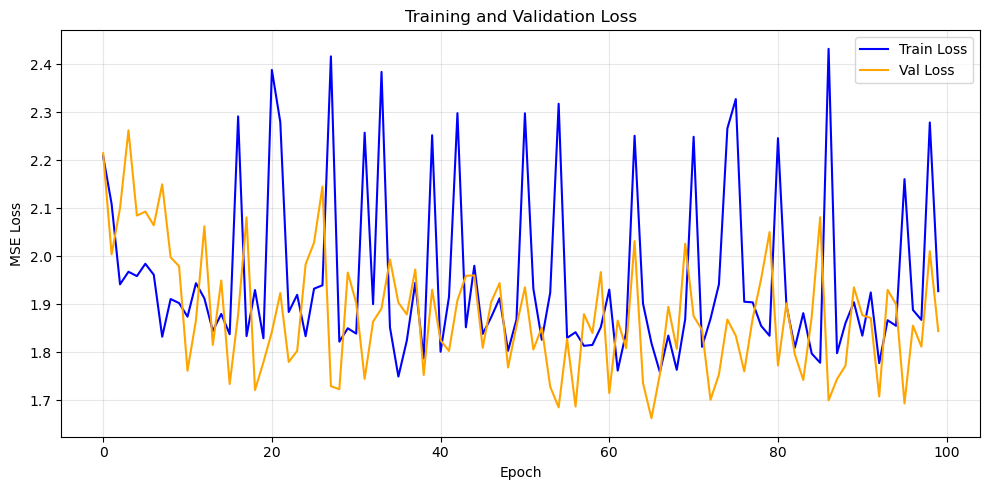

Test Loss: 1.723216


In [12]:
# Plot training curves
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(train_losses, label='Train Loss', color='blue')
ax.plot(val_losses, label='Val Loss', color='orange')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Training and Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Evaluate on test set
test_loss = evaluate(model, test_loader, device, MASK_RATIO)
print(f"Test Loss: {test_loss:.6f}")


# 3. Sequence-Level DMoN Clustering

Now we apply DMoN clustering at the **sequence level** (not chirp level):

1. **Stage 2: Sequence Construction** - Create non-overlapping 4-grams with positional encodings
2. **Stage 3: Sequence Embedding** - MLP projects 128-dim → 32-dim  
3. **k-NN Graph** - Build graph over sequences (weighted by same-recording)
4. **DMoN Clustering** - Cluster sequences using modularity optimization
5. **Joint Fine-tuning** - Optimize reconstruction + sequence clustering together


In [13]:
@torch.no_grad()
def extract_chirp_embeddings(gat_model, graphs, device):
    """
    Extract GAT embeddings for all chirps in all recordings.
    
    Returns:
        List of embedding tensors, one per recording
    """
    gat_model.eval()
    all_embeddings = []
    
    for graph in tqdm(graphs, desc="Extracting chirp embeddings"):
        graph = graph.to(device)
        h = gat_model.encode(graph.x, graph.edge_index, graph.edge_attr)
        all_embeddings.append(h.cpu())
    
    return all_embeddings

# Extract initial embeddings from pre-trained GAT
print("Extracting chirp embeddings from pre-trained GAT...")
all_chirp_embeddings = extract_chirp_embeddings(model, graphs, device)
print(f"Extracted embeddings for {len(all_chirp_embeddings)} recordings")
print(f"Total chirps: {sum(e.shape[0] for e in all_chirp_embeddings):,}")

Extracting chirp embeddings from pre-trained GAT...


Extracting chirp embeddings: 100%|██████████| 2929/2929 [00:44<00:00, 65.10it/s] 

Extracted embeddings for 2929 recordings
Total chirps: 41,774


### Sequence-Level DMoN Architecture

We implement DMoN (Deep Modularity Networks) at the **sequence level**:

1. **Sequence Construction**: Non-overlapping 4-grams with positional encodings
2. **Sequence MLP**: Projects 128-dim concatenation → 32-dim embedding
3. **k-NN Graph**: Built over sequence embeddings (k=20, same-recording weighted)
4. **DMoN Cluster Head**: Soft assignment to k=10 clusters
5. **DMoN Loss**: Modularity maximization + collapse regularization

In [64]:
import math

# ============================================================================
# HYPERPARAMETERS
# ============================================================================
SEQ_LEN = 4                    # 4-gram sequences
NUM_SEQ_CLUSTERS = 2           # Number of sequence clusters
K_NEIGHBORS = 20               # k-NN graph neighbors
KNN_UPDATE_FREQ = 5            # Rebuild k-NN graph every N epochs
SAME_RECORDING_WEIGHT = 2.0    # Higher weight for same-recording edges
LAMBDA_DMON = 1.0              # Weight for DMoN loss vs reconstruction

# ============================================================================
# SEQUENCE DMON MODULE
# ============================================================================
class SequenceDMoN(nn.Module):
    """
    Stages 2 & 3: Sequence construction, embedding, and DMoN clustering.
    
    Architecture:
        Stage 2: Positional encodings + concatenation
            - Learnable position embeddings P ∈ ℝ^(4 × 32)
            - h_seq = [h_1 + p_1 || h_2 + p_2 || h_3 + p_3 || h_4 + p_4] ∈ ℝ^128
        
        Stage 3: Sequence MLP + DMoN cluster head
            - MLP: 128 → 64 → 32 (with SELU, dropout)
            - Cluster head: Linear(32 → k) + Softmax
    """
    
    def __init__(self, chirp_dim=32, seq_len=4, hidden_dim=64, seq_embed_dim=32,
                 num_clusters=10, dropout=0.2, cluster_dropout=0.5):
        super().__init__()
        
        self.chirp_dim = chirp_dim
        self.seq_len = seq_len
        self.seq_embed_dim = seq_embed_dim
        self.num_clusters = num_clusters
        
        # Learnable positional embeddings
        self.positional_embeddings = nn.Parameter(torch.randn(seq_len, chirp_dim) * 0.02)
        
        # Sequence MLP (128 → 64 → 32)
        concat_dim = chirp_dim * seq_len  # 32 * 4 = 128
        self.sequence_mlp = nn.Sequential(
            nn.Linear(concat_dim, hidden_dim),
            nn.SELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, seq_embed_dim)
        )
        
        # DMoN cluster head
        self.cluster_head = nn.Linear(seq_embed_dim, num_clusters)
        self.cluster_dropout = nn.Dropout(cluster_dropout)
    
    def build_sequences(self, chirp_embeddings_list, file_ids):
        """
        Build non-overlapping 4-gram sequences from chirp embeddings.
        
        Returns:
            seq_embeddings: [N_seq, 128] concatenated chirp+positional embeddings
            seq_file_ids: [N_seq] file ID for each sequence
            seq_metadata: List of dicts with sequence info
        """
        all_sequences = []
        all_file_ids = []
        metadata = []
        
        for chirp_emb, file_id in zip(chirp_embeddings_list, file_ids):
            n_chirps = chirp_emb.shape[0]
            n_seqs = n_chirps // self.seq_len
            
            for i in range(n_seqs):
                start_idx = i * self.seq_len
                chirps = chirp_emb[start_idx:start_idx + self.seq_len]  # [4, 32]
                chirps_with_pos = chirps + self.positional_embeddings   # [4, 32]
                seq = chirps_with_pos.reshape(-1)                       # [128]
                
                all_sequences.append(seq)
                all_file_ids.append(file_id)
                metadata.append({
                    'file_id': file_id,
                    'start_idx': start_idx,
                    'end_idx': start_idx + self.seq_len
                })
        
        if all_sequences:
            seq_embeddings = torch.stack(all_sequences)
            seq_file_ids = torch.tensor(all_file_ids)
        else:
            seq_embeddings = torch.empty(0, self.chirp_dim * self.seq_len)
            seq_file_ids = torch.empty(0, dtype=torch.long)
        
        return seq_embeddings, seq_file_ids, metadata
    
    def forward(self, seq_embeddings):
        """
        Forward pass: sequence MLP → cluster assignments.
        
        Returns:
            S: [N_seq, 32] sequence embeddings
            C: [N_seq, k] soft cluster assignments
        """
        S = self.sequence_mlp(seq_embeddings)
        S_dropped = self.cluster_dropout(S)
        C = F.softmax(self.cluster_head(S_dropped), dim=-1)
        return S, C


# Initialize
seq_dmon = SequenceDMoN(
    chirp_dim=32, seq_len=SEQ_LEN, hidden_dim=64, seq_embed_dim=32,
    num_clusters=NUM_SEQ_CLUSTERS, dropout=0.2, cluster_dropout=0.5
).to(device)

print(f"SequenceDMoN architecture:\n{seq_dmon}")
print(f"\nParameters: {sum(p.numel() for p in seq_dmon.parameters()):,}")

SequenceDMoN architecture:
SequenceDMoN(
  (sequence_mlp): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): SELU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
  )
  (cluster_head): Linear(in_features=32, out_features=2, bias=True)
  (cluster_dropout): Dropout(p=0.5, inplace=False)
)

Parameters: 10,530


In [65]:
# ============================================================================
# K-NN GRAPH BUILDER (MPS-COMPATIBLE)
# ============================================================================

def build_knn_graph(seq_embeddings, seq_file_ids, k=20, same_recording_weight=2.0):
    """
    Build k-NN graph over sequence embeddings with same-recording weighting.
    
    Uses cosine distance for similarity calculation.
    MPS-compatible: uses CPU fallback for unsupported operations.
    
    Args:
        seq_embeddings: [N_seq, dim] sequence embeddings
        seq_file_ids: [N_seq] file ID for each sequence
        k: Number of nearest neighbors
        same_recording_weight: Weight multiplier for same-recording edges
        
    Returns:
        edge_index: [2, num_edges] sparse edge indices (on same device as input)
        edge_weights: [num_edges] edge weights (on same device as input)
    """
    N = seq_embeddings.shape[0]
    device = seq_embeddings.device
    
    # Compute pairwise cosine distances
    # Normalize embeddings for cosine similarity
    normalized = F.normalize(seq_embeddings, p=2, dim=1)
    # Cosine similarity = dot product of normalized vectors
    cosine_sim = torch.mm(normalized, normalized.t())
    # Convert to distance: cosine_distance = 1 - cosine_similarity
    dists = 1.0 - cosine_sim
    dists.fill_diagonal_(float('inf'))  # Exclude self-loops
    
    # Get k nearest neighbors
    actual_k = min(k, N - 1)
    _, knn_indices = torch.topk(dists, actual_k, dim=1, largest=False)
    
    # Build edge index
    source = torch.arange(N, device=device).unsqueeze(1).expand(-1, actual_k).reshape(-1)
    target = knn_indices.reshape(-1)
    
    # Make bidirectional
    edge_index = torch.stack([
        torch.cat([source, target]),
        torch.cat([target, source])
    ])
    
    # Remove duplicates - move to CPU for unique (not supported on MPS)
    edge_index_cpu = edge_index.cpu()
    edge_index_unique = torch.unique(edge_index_cpu, dim=1)
    edge_index = edge_index_unique.to(device)
    
    # Compute edge weights (higher for same recording)
    src_fids = seq_file_ids[edge_index[0]]
    tgt_fids = seq_file_ids[edge_index[1]]
    same_recording = (src_fids == tgt_fids).float()
    edge_weights = 1.0 + (same_recording_weight - 1.0) * same_recording
    
    return edge_index, edge_weights


print("k-NN graph builder defined (MPS-compatible)")
print(f"  - k = {K_NEIGHBORS} neighbors")
print(f"  - Same-recording weight = {SAME_RECORDING_WEIGHT}x")

k-NN graph builder defined (MPS-compatible)
  - k = 20 neighbors
  - Same-recording weight = 2.0x


In [66]:
# ============================================================================
# DMON LOSS FUNCTIONS (MPS-COMPATIBLE)
# ============================================================================

def modularity_loss(C, edge_index, edge_weights, num_nodes):
    """
    Compute modularity loss for DMoN.
    
    L_mod = -(1/2m) * Tr(C^T B C)
    
    MPS-compatible: uses dense operations to avoid sparse tensor issues.
    """
    device = C.device
    
    # Total edge weight
    m = edge_weights.sum() / 2
    if m == 0:
        return torch.tensor(0.0, device=device)
    
    # Build adjacency matrix using scatter_add (MPS-compatible)
    # Instead of sparse tensors, use index_add
    A = torch.zeros(num_nodes, num_nodes, device=device)
    
    # Add edge weights to adjacency matrix
    src, tgt = edge_index[0], edge_index[1]
    A[src, tgt] = edge_weights
    
    # Weighted degree
    d = A.sum(dim=1)  # [num_nodes]
    
    # Term 1: Tr(C^T A C) = sum of element-wise product of C and (A @ C)
    AC = A @ C  # [num_nodes, k]
    term1 = (C * AC).sum()
    
    # Term 2: (d^T C)^2 / 2m = ||d @ C||^2 / 2m
    dC = d @ C  # [k]
    term2 = (dC ** 2).sum() / (2 * m)
    
    # Modularity = (term1 - term2) / 2m
    # Return negative modularity (to minimize)
    modularity = (term1 - term2) / (2 * m)
    return -modularity


def collapse_loss(C):
    """
    Collapse regularization to prevent all nodes going to one cluster.
    
    L_collapse = (sqrt(k) / N) * ||sum_i C_i||_F - 1
    """
    N, k = C.shape
    cluster_sizes = C.sum(dim=0)
    return (math.sqrt(k) / N) * torch.norm(cluster_sizes) - 1


def dmon_loss(C, edge_index, edge_weights, num_nodes):
    """
    Combined DMoN loss.
    
    Returns: total_loss, modularity_loss, collapse_loss
    """
    DEWEIGHTING_LAMBDA = 1
    L_mod = modularity_loss(C, edge_index, edge_weights, num_nodes)
    L_col = collapse_loss(C)
    return L_mod + DEWEIGHTING_LAMBDA * L_col, L_mod, L_col


print("DMoN loss functions defined (MPS-compatible)")
print("  - modularity_loss: Uses dense operations for MPS compatibility")
print("  - collapse_loss: Prevents cluster collapse")

DMoN loss functions defined (MPS-compatible)
  - modularity_loss: Uses dense operations for MPS compatibility
  - collapse_loss: Prevents cluster collapse


In [67]:
# Build sequences and initial k-NN graph
print("Building 4-gram sequences...")

seq_dmon.eval()
with torch.no_grad():
    chirp_embs_device = [e.to(device) for e in all_chirp_embeddings]
    seq_embeddings, seq_file_ids, seq_metadata = seq_dmon.build_sequences(chirp_embs_device, file_ids)
    seq_embeddings = seq_embeddings.to(device)
    seq_file_ids = seq_file_ids.to(device)

print(f"Built {len(seq_embeddings):,} non-overlapping 4-gram sequences")
print(f"Sequence embedding shape: {seq_embeddings.shape}")

# Build initial k-NN graph
print("\nBuilding k-NN graph...")
with torch.no_grad():
    S_init, _ = seq_dmon(seq_embeddings)
    edge_index, edge_weights = build_knn_graph(
        S_init, seq_file_ids, k=K_NEIGHBORS, same_recording_weight=SAME_RECORDING_WEIGHT
    )
    edge_index = edge_index.to(device)
    edge_weights = edge_weights.to(device)

print(f"k-NN graph edges: {edge_index.shape[1]:,}")
same_rec = (seq_file_ids[edge_index[0]] == seq_file_ids[edge_index[1]]).sum().item()
print(f"Same-recording edges: {same_rec:,} ({100*same_rec/edge_index.shape[1]:.1f}%)")

Building 4-gram sequences...
Built 9,422 non-overlapping 4-gram sequences
Sequence embedding shape: torch.Size([9422, 128])

Building k-NN graph...
k-NN graph edges: 297,562
Same-recording edges: 1,558 (0.5%)


### Joint Training: Reconstruction + Sequence DMoN

We fine-tune the GAT encoder jointly with the Sequence DMoN module:

**Loss Function:**
$$L_{total} = L_{reconstruction} + \lambda_{DMoN} \cdot L_{DMoN}$$

where:
- $L_{reconstruction}$ = MSE on masked chirp features
- $L_{DMoN} = L_{modularity} + L_{collapse}$

In [68]:
# ============================================================================
# JOINT TRAINING: RECONSTRUCTION + SEQUENCE DMON
# ============================================================================

print("=" * 70)
print("JOINT TRAINING: Reconstruction + Sequence-Level DMoN")
print("=" * 70)

# Hyperparameters
JOINT_EPOCHS = 50
JOINT_LR = 5e-4
JOINT_PATIENCE = 15

# Combine parameters
all_params = list(model.parameters()) + list(seq_dmon.parameters())
joint_optimizer = torch.optim.Adam(all_params, lr=JOINT_LR, weight_decay=WEIGHT_DECAY)
joint_scheduler = ReduceLROnPlateau(joint_optimizer, mode='min', factor=0.5, patience=5, verbose=False)

# Training history
history = {'total': [], 'recon': [], 'dmon': [], 'mod': [], 'col': []}
best_loss = float('inf')
best_gat_state = None
best_dmon_state = None
patience_counter = 0

print(f"Epochs: {JOINT_EPOCHS}, LR: {JOINT_LR}, λ_DMoN: {LAMBDA_DMON}")
print(f"k-NN rebuild every {KNN_UPDATE_FREQ} epochs")
print("-" * 70)

for epoch in range(JOINT_EPOCHS):
    
    seq_dmon.train()
    
    # === RECONSTRUCTION LOSS (on training batches) ===
    total_recon = 0
    for batch in train_loader:
        batch = batch.to(device)
        joint_optimizer.zero_grad()
        
        mask = create_mask(batch.num_nodes, MASK_RATIO).to(device)
        h, x_hat, _ = model(batch.x, batch.edge_index, batch.edge_attr, mask)
        L_recon = F.mse_loss(x_hat, batch.x[mask])
        total_recon += L_recon.item()
    
    avg_recon = total_recon / len(train_loader)
    
    # === SEQUENCE DMON LOSS ===
    with torch.no_grad():
        chirp_embs = [model.encode(g.to(device).x, g.to(device).edge_index, g.to(device).edge_attr) 
                      for g in graphs]
    
    
    # Build sequences
    seq_embs, seq_fids, _ = seq_dmon.build_sequences(chirp_embs, file_ids)
    seq_embs = seq_embs.to(device)
    seq_fids = seq_fids.to(device)
    
    # Update k-NN graph periodically
    if epoch % KNN_UPDATE_FREQ == 0:
        with torch.no_grad():
            S_temp, _ = seq_dmon(seq_embs)
            edge_index, edge_weights = build_knn_graph(
                S_temp, seq_fids, K_NEIGHBORS, SAME_RECORDING_WEIGHT
            )
            edge_index = edge_index.to(device)
            edge_weights = edge_weights.to(device)
    
    # Forward through DMoN
    S, C = seq_dmon(seq_embs)
    L_dmon, L_mod, L_col = dmon_loss(C, edge_index, edge_weights, len(seq_embs))
    
    # Backward for DMoN loss
    (LAMBDA_DMON * L_dmon).backward()
    joint_optimizer.step()
    
    # Record
    L_total = avg_recon + LAMBDA_DMON * L_dmon.item()
    history['total'].append(L_total)
    history['recon'].append(avg_recon)
    history['dmon'].append(L_dmon.item())
    history['mod'].append(L_mod.item())
    history['col'].append(L_col.item())
    
    joint_scheduler.step(L_total)
    
    # Early stopping
    if L_total < best_loss:
        best_loss = L_total
        best_gat_state = model.state_dict().copy()
        best_dmon_state = seq_dmon.state_dict().copy()
        patience_counter = 0
        mark = "✓"
    else:
        patience_counter += 1
        mark = ""
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d} | Total: {L_total:.4f} | Recon: {avg_recon:.4f} | "
              f"DMoN: {L_dmon.item():.4f} (mod: {L_mod.item():.3f}, col: {L_col.item():.3f}) {mark}")
    
    if patience_counter >= JOINT_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

# Load best
model.load_state_dict(best_gat_state)
seq_dmon.load_state_dict(best_dmon_state)
print(f"\n{'='*70}")
print(f"Training complete! Best loss: {best_loss:.4f}")

JOINT TRAINING: Reconstruction + Sequence-Level DMoN


Epochs: 50, LR: 0.0005, λ_DMoN: 1.0
k-NN rebuild every 5 epochs
----------------------------------------------------------------------


/opt/anaconda3/envs/BatGPT/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch   1 | Total: 1.8019 | Recon: 1.8048 | DMoN: -0.0029 (mod: -0.003, col: 0.000) ✓
Epoch   5 | Total: 1.7578 | Recon: 1.7771 | DMoN: -0.0193 (mod: -0.019, col: 0.000) ✓
Epoch  10 | Total: 1.8146 | Recon: 1.8850 | DMoN: -0.0704 (mod: -0.070, col: 0.000) 
Epoch  15 | Total: 1.8007 | Recon: 1.9253 | DMoN: -0.1246 (mod: -0.125, col: 0.000) 
Epoch  20 | Total: 1.7279 | Recon: 1.8984 | DMoN: -0.1705 (mod: -0.171, col: 0.000) 
Epoch  25 | Total: 2.0915 | Recon: 2.2882 | DMoN: -0.1967 (mod: -0.197, col: 0.000) 
Epoch  30 | Total: 2.0523 | Recon: 2.2689 | DMoN: -0.2166 (mod: -0.217, col: 0.000) 
Epoch  35 | Total: 1.5995 | Recon: 1.8378 | DMoN: -0.2383 (mod: -0.239, col: 0.001) 
Epoch  40 | Total: 1.5193 | Recon: 1.7768 | DMoN: -0.2575 (mod: -0.258, col: 0.001) 
Epoch  45 | Total: 1.6119 | Recon: 1.8777 | DMoN: -0.2658 (mod: -0.266, col: 0.001) 
Epoch  50 | Total: 1.7348 | Recon: 2.0067 | DMoN: -0.2719 (mod: -0.273, col: 0.001) 

Training complete! Best loss: 1.4734


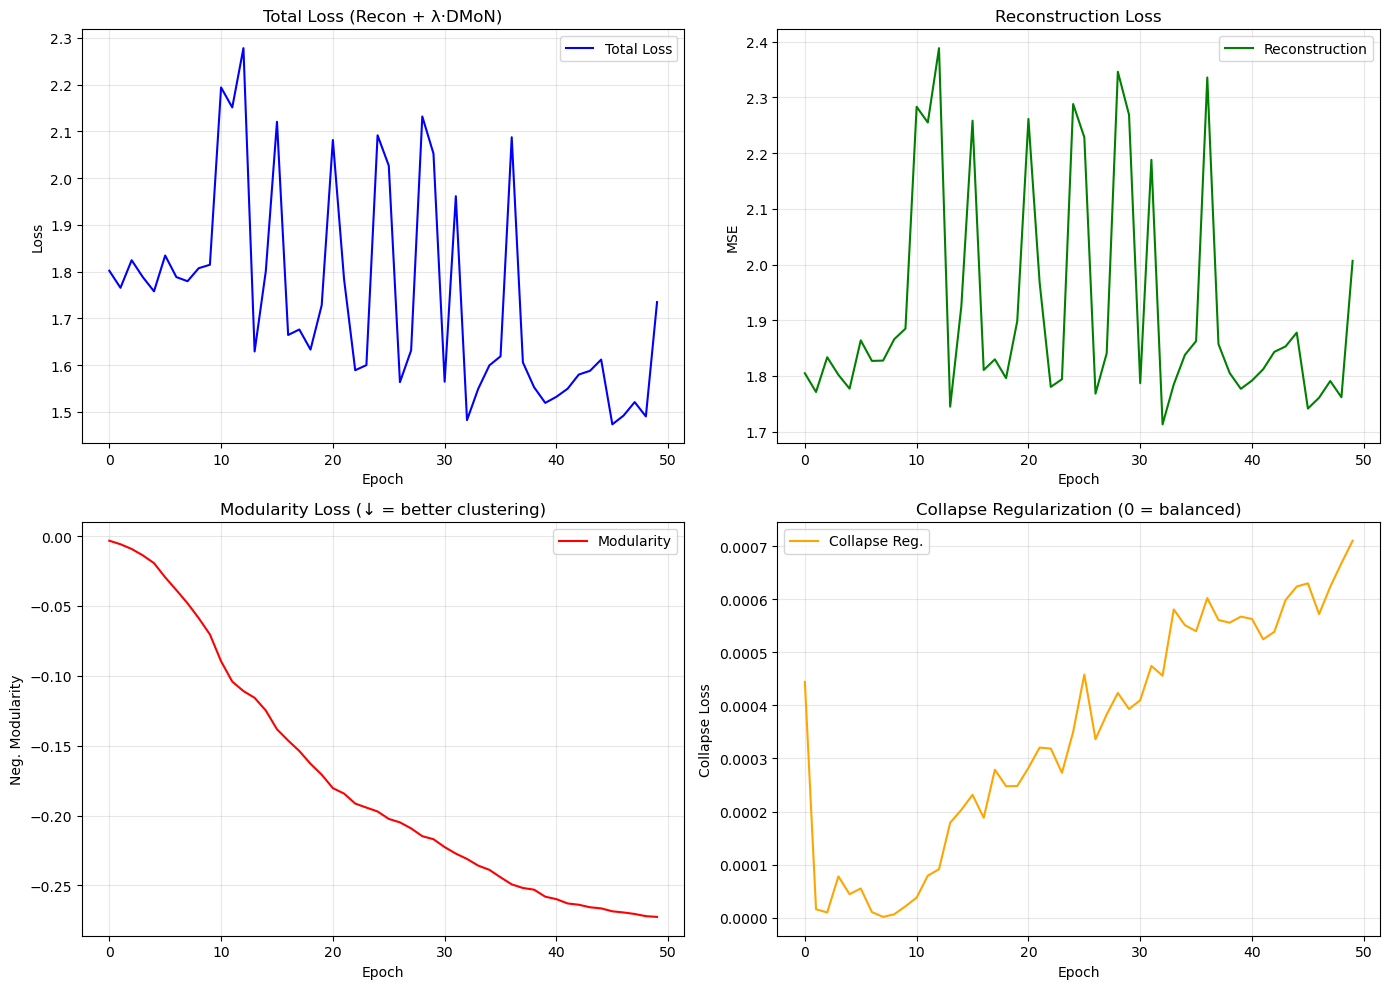

In [69]:
# Plot training curves
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
ax1.plot(history['total'], 'b-', label='Total Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Total Loss (Recon + λ·DMoN)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
ax2.plot(history['recon'], 'g-', label='Reconstruction')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MSE')
ax2.set_title('Reconstruction Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
ax3.plot(history['mod'], 'r-', label='Modularity')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Neg. Modularity')
ax3.set_title('Modularity Loss (↓ = better clustering)')
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4 = axes[1, 1]
ax4.plot(history['col'], 'orange', label='Collapse Reg.')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Collapse Loss')
ax4.set_title('Collapse Regularization (0 = balanced)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Cluster Analysis

We extract the final cluster assignments from the trained DMoN model and analyze:
1. **Cluster distribution** across sequences
2. **UMAP visualization** of sequence embeddings colored by cluster
3. **Transition patterns** between clusters within recordings

In [70]:
# Extract final cluster assignments
print("Extracting final cluster assignments...")

model.eval()
seq_dmon.eval()

with torch.no_grad():
    # Get final chirp embeddings
    final_chirp_embs = [model.encode(g.to(device).x, g.to(device).edge_index, g.to(device).edge_attr) 
                        for g in graphs]
    
    # Build sequences
    final_seq_embs, final_seq_fids, final_seq_meta = seq_dmon.build_sequences(final_chirp_embs, file_ids)
    final_seq_embs = final_seq_embs.to(device)
    
    # Get embeddings and cluster assignments
    S_final, C_final = seq_dmon(final_seq_embs)
    
    # Convert to numpy
    cluster_ids = C_final.argmax(dim=1).cpu().numpy()
    cluster_probs = C_final.cpu().numpy()
    S_np = S_final.cpu().numpy()
    seq_fids_np = final_seq_fids.cpu().numpy()

# Cluster distribution
from collections import Counter
cluster_counts = Counter(cluster_ids)

print(f"\nTotal sequences: {len(cluster_ids):,}")
print(f"Sequence embedding dim: {S_np.shape[1]}")
print(f"\nCluster distribution:")
for c in range(NUM_SEQ_CLUSTERS):
    count = cluster_counts.get(c, 0)
    pct = 100 * count / len(cluster_ids)
    print(f"  Cluster {c}: {count:,} sequences ({pct:.1f}%)")

Extracting final cluster assignments...

Total sequences: 9,422
Sequence embedding dim: 32

Cluster distribution:
  Cluster 0: 4,458 sequences (47.3%)
  Cluster 1: 4,964 sequences (52.7%)


Computing UMAP projection...


/opt/anaconda3/envs/BatGPT/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Silhouette Score: 0.4970
Calinski-Harabasz Score: 16568.6602


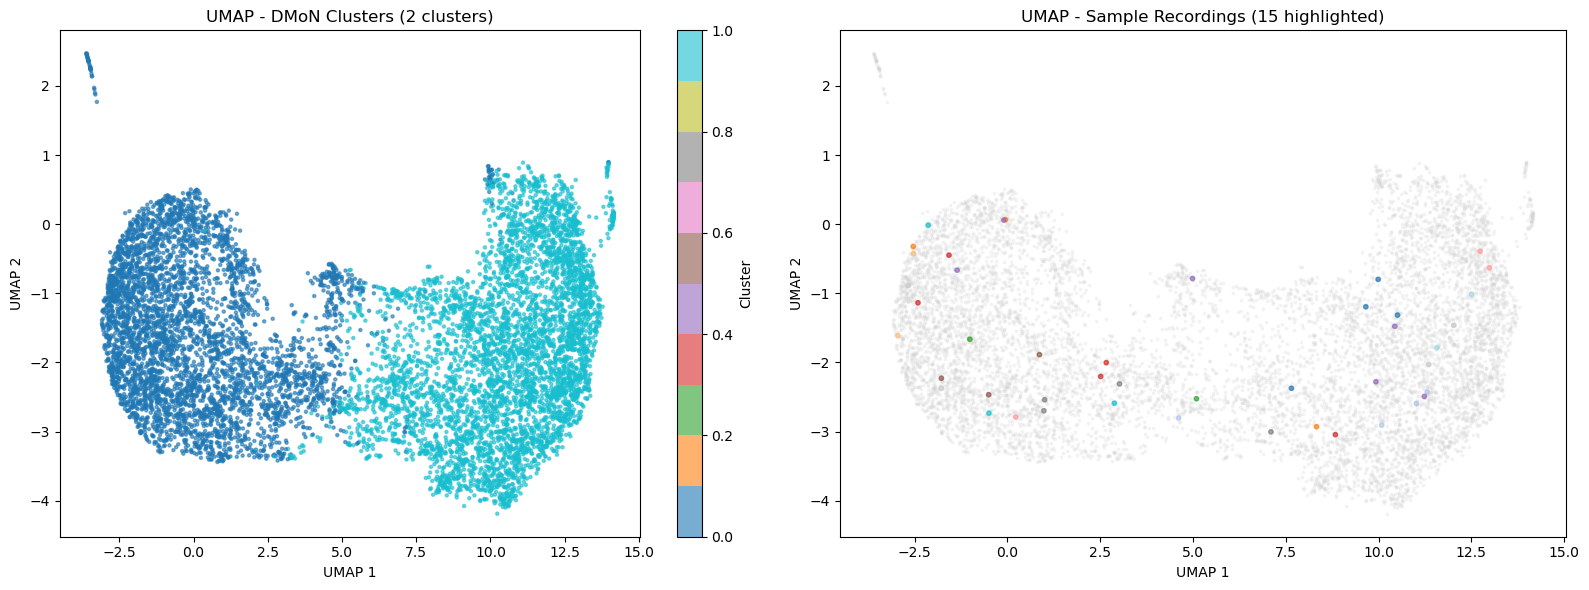

In [71]:
# UMAP visualization
import umap
from sklearn.metrics import silhouette_score, calinski_harabasz_score

print("Computing UMAP projection...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, metric='cosine', random_state=42)
S_2d = reducer.fit_transform(S_np)

# Clustering evaluation metrics
if len(np.unique(cluster_ids)) > 1:
    sil_score = silhouette_score(S_np, cluster_ids)
    ch_score = calinski_harabasz_score(S_np, cluster_ids)
    print(f"Silhouette Score: {sil_score:.4f}")
    print(f"Calinski-Harabasz Score: {ch_score:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Clusters
ax1 = axes[0]
scatter1 = ax1.scatter(S_2d[:, 0], S_2d[:, 1], c=cluster_ids, cmap='tab10', s=5, alpha=0.6)
ax1.set_title(f'UMAP - DMoN Clusters ({NUM_SEQ_CLUSTERS} clusters)')
ax1.set_xlabel('UMAP 1')
ax1.set_ylabel('UMAP 2')
plt.colorbar(scatter1, ax=ax1, label='Cluster')

# Sample recordings
ax2 = axes[1]
unique_recs = np.unique(seq_fids_np)
sample_recs = np.random.choice(unique_recs, min(15, len(unique_recs)), replace=False)
sample_mask = np.isin(seq_fids_np, sample_recs)

ax2.scatter(S_2d[~sample_mask, 0], S_2d[~sample_mask, 1], c='lightgray', s=3, alpha=0.2)
scatter2 = ax2.scatter(S_2d[sample_mask, 0], S_2d[sample_mask, 1], 
                       c=seq_fids_np[sample_mask], cmap='tab20', s=10, alpha=0.7)
ax2.set_title(f'UMAP - Sample Recordings ({len(sample_recs)} highlighted)')
ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')

plt.tight_layout()
plt.show()

In [72]:
# Cluster transition analysis
print("\n" + "="*70)
print("CLUSTER TRANSITION ANALYSIS")
print("="*70)

# Build transition matrix
from collections import defaultdict

transitions = np.zeros((NUM_SEQ_CLUSTERS, NUM_SEQ_CLUSTERS))
seqs_by_rec = defaultdict(list)

for idx, meta in enumerate(final_seq_meta):
    seqs_by_rec[meta['file_id']].append((meta['start_idx'], cluster_ids[idx]))

for file_id, seqs in seqs_by_rec.items():
    seqs_sorted = sorted(seqs, key=lambda x: x[0])
    for i in range(len(seqs_sorted) - 1):
        from_c = seqs_sorted[i][1]
        to_c = seqs_sorted[i + 1][1]
        transitions[from_c, to_c] += 1

# Normalize
row_sums = transitions.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
trans_probs = transitions / row_sums

print("\nTransition probabilities (>10%):")
for i in range(NUM_SEQ_CLUSTERS):
    for j in range(NUM_SEQ_CLUSTERS):
        if trans_probs[i, j] > 0.1:
            print(f"  Cluster {i} → {j}: {trans_probs[i, j]:.1%}")

print("\nSelf-transition rates (persistence):")
for i in range(NUM_SEQ_CLUSTERS):
    print(f"  Cluster {i}: {trans_probs[i, i]:.1%}")


CLUSTER TRANSITION ANALYSIS

Transition probabilities (>10%):
  Cluster 0 → 0: 79.6%
  Cluster 0 → 1: 20.4%
  Cluster 1 → 0: 22.1%
  Cluster 1 → 1: 77.9%

Self-transition rates (persistence):
  Cluster 0: 79.6%
  Cluster 1: 77.9%


In [73]:
# Save results
import pickle

results = {
    # Config
    'num_clusters': NUM_SEQ_CLUSTERS,
    'seq_len': SEQ_LEN,
    'k_neighbors': K_NEIGHBORS,
    'lambda_dmon': LAMBDA_DMON,
    
    # Results
    'sequence_embeddings': S_np,
    'cluster_ids': cluster_ids,
    'cluster_probs': cluster_probs,
    'sequence_metadata': final_seq_meta,
    'umap_2d': S_2d,
    
    # Analysis
    'transition_probs': trans_probs,
    'cluster_counts': dict(cluster_counts),
    
    # Training
    'history': history
}

with open('sequence_dmon_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print("Results saved to 'sequence_dmon_results.pkl'")

Results saved to 'sequence_dmon_results.pkl'


# 5. Summary

## Sequence-Level DMoN Clustering Results

This notebook implemented:

1. **Stage 1: GAT Encoder** - Context-aware chirp embeddings via masked reconstruction
2. **Stage 2: Sequence Construction** - Non-overlapping 4-grams with positional encodings  
3. **Stage 3: Sequence DMoN** - k-NN graph + modularity-based clustering

### Key Outputs:
- **Sequence embeddings**: 32-dim representations for each 4-gram
- **Cluster assignments**: Soft probabilities for k clusters per sequence
- **Transition patterns**: How clusters flow within recordings

### Architecture Summary:
```
Chirps → GAT Encoder → 32-dim embeddings
    ↓
4-grams + positional enc → 128-dim
    ↓
Sequence MLP → 32-dim sequence embeddings
    ↓
k-NN Graph (same-recording weighted)
    ↓
DMoN Cluster Head → k soft cluster assignments
```